In [9]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio

import nymeria_gaze_tools as ngt

pio.renderers.default = "notebook_connected"

DATA_ROOT      = Path("../data/processed")
SUMMARIES_PATH = DATA_ROOT / "all_session_summaries.csv"
FIGURES_DIR    = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


In [10]:
catalog_raw = ngt.load_metadata(data_root=DATA_ROOT)
summaries   = pd.read_csv(SUMMARIES_PATH)

# --- Standard filter block ---
catalog = catalog_raw.copy()
catalog = catalog[catalog["sampling_rate_hz"] == 10]
catalog = catalog[catalog["noise_flag"] == False]
catalog = catalog[catalog["has_gaze_data"] == True]
catalog = catalog[catalog["has_two_participants"] == False]
catalog = (catalog
           .sort_values("date")
           .drop_duplicates(["fake_name", "script"])
           .reset_index(drop=True))

print(f"Sessions: {len(catalog)}  |  Participants: {catalog['fake_name'].nunique()}")
print(f"\nSessions per activity:")
print(catalog.groupby("script").size().sort_values(ascending=False).to_string())

Sessions: 810  |  Participants: 193

Sessions per activity:
script
S7-Cooking                97
S2-Where_is_X             96
S12-Game_night            89
S16-Simon_says            85
S19-Fresh_air             55
S10-Housekeeping          54
S8-Having_a_meal          46
S3-Welcome_to_my_place    39
S11-Laundary              28
S13-Charades              27
S5-Workout                26
S15-Do_as_I_command       25
S6-Dance                  22
S1-Relax_at_home          22
S17-In_the_office         20
S4-Body_stretch           19
S9-Making_a_mess          19
S18-Hike                  17
S20-Party                 13
S14-By_my_desk            11


In [11]:
print(f"Loading {len(catalog)} sessions...")
session_dfs = {}
skipped = []

for i, (_, row) in enumerate(catalog.iterrows()):
    if i % 100 == 0:
        print(f"  {i}/{len(catalog)}")
    try:
        raw = ngt.load_session(row["sequence_uid"], data_root=DATA_ROOT)
        session_dfs[row["sequence_uid"]] = ngt.preprocess(
            raw,
            trim_start_min=row["trim_start_sec"] / 60,
            trim_end_min=row["trim_end_sec"] / 60,
        )
    except Exception as e:
        skipped.append((row["sequence_uid"], row["script"], str(e)))

print(f"\nDone. Loaded: {len(session_dfs)}  |  Skipped: {len(skipped)}")
for uid, script, err in skipped:
    print(f"  SKIP {script} | {uid} | {err}")


Loading 810 sessions...
  0/810
  100/810
  200/810
  300/810
  400/810
  500/810
  600/810
  700/810
  800/810

Done. Loaded: 809  |  Skipped: 1
  SKIP S6-Dance | 20230726_s1_thomas_nixon_act2_bsfnuw | 'left_yaw_rads_cpf'


In [12]:
# Group preprocessed DataFrames by activity
activity_groups = {}
for _, row in catalog.iterrows():
    uid = row["sequence_uid"]
    if uid not in session_dfs:
        continue
    script = row["script"]
    if script not in activity_groups:
        activity_groups[script] = []
    activity_groups[script].append(session_dfs[uid])

print("Sessions per activity (loaded):")
for script, dfs in sorted(activity_groups.items()):
    print(f"  {script:<35} {len(dfs)}")


Sessions per activity (loaded):
  S1-Relax_at_home                    22
  S10-Housekeeping                    54
  S11-Laundary                        28
  S12-Game_night                      89
  S13-Charades                        27
  S14-By_my_desk                      11
  S15-Do_as_I_command                 25
  S16-Simon_says                      85
  S17-In_the_office                   20
  S18-Hike                            17
  S19-Fresh_air                       55
  S2-Where_is_X                       96
  S20-Party                           13
  S3-Welcome_to_my_place              39
  S4-Body_stretch                     19
  S5-Workout                          26
  S6-Dance                            21
  S7-Cooking                          97
  S8-Having_a_meal                    46
  S9-Making_a_mess                    19


In [13]:
activity = "S7-Cooking"

fig = ngt.plot_population_density(
    activity_groups[activity],
    title=f"{activity}  (n={len(activity_groups[activity])} participants)"
)
fig.show()


In [15]:
# Build one row per participant per activity
rows = []
for _, meta_row in catalog.iterrows():
    uid = meta_row["sequence_uid"]
    if uid not in session_dfs:
        continue
    df = session_dfs[uid]
    rows.append({
        "script":     meta_row["script"],
        "fake_name":  meta_row["fake_name"],
        "mean_yaw":   df["avg_yaw_deg"].mean(),
        "mean_pitch": df["pitch_deg"].mean(),
    })

participant_means = pd.DataFrame(rows)

# Average across participants per activity
centroids = (participant_means
             .groupby("script")
             .agg(
                 centroid_yaw   = ("mean_yaw",   "mean"),
                 centroid_pitch = ("mean_pitch",  "mean"),
                 yaw_se         = ("mean_yaw",   "sem"),
                 pitch_se       = ("mean_pitch", "sem"),
                 n              = ("fake_name",  "count"),
             )
             .reset_index())

print(centroids.sort_values("centroid_pitch").to_string())


                    script  centroid_yaw  centroid_pitch    yaw_se  pitch_se   n
17              S7-Cooking     -0.185811      -24.173930  0.216911  0.565328  97
2             S11-Laundary     -1.467380      -23.249288  0.382068  1.171910  28
12               S20-Party      0.770476      -22.045968  0.511901  1.094097  13
5           S14-By_my_desk      0.893143      -21.637666  0.898033  1.726019  11
1         S10-Housekeeping     -0.176776      -21.178431  0.272652  0.723588  54
18        S8-Having_a_meal     -0.004549      -20.414237  0.362617  0.889868  46
3           S12-Game_night     -0.590211      -20.341244  0.252623  0.604013  89
9                 S18-Hike      0.903323      -18.918486  0.502643  1.044961  17
19        S9-Making_a_mess     -1.146133      -18.892105  0.675251  1.309602  19
16                S6-Dance     -0.701599      -18.678793  0.662814  1.876906  21
7           S16-Simon_says      0.136835      -18.101159  0.240283  0.677008  85
15              S5-Workout  

In [16]:
import math
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

EXCLUDE_ACTIVITIES = ["S16-Simon_says"]
N_COLS = 4
BINS   = 80
PANEL_SIZE = 300

activity_order = (centroids[~centroids["script"].isin(EXCLUDE_ACTIVITIES)]
                  .sort_values("centroid_pitch")["script"]
                  .tolist())

groups = {act: activity_groups[act] for act in activity_order}
labels = list(groups.keys())
n      = len(labels)
n_rows = math.ceil(n / N_COLS)

# Shared axis ranges so gaze positions are comparable across panels
all_dfs  = [df for dfs in groups.values() for df in dfs]
x_all    = pd.concat([df["avg_yaw_deg"].dropna() for df in all_dfs])
y_all    = pd.concat([df["pitch_deg"].dropna()   for df in all_dfs])
x_edges  = np.linspace(x_all.min(), x_all.max(), BINS + 1)
y_edges  = np.linspace(y_all.min(), y_all.max(), BINS + 1)
x_ctr    = (x_edges[:-1] + x_edges[1:]) / 2
y_ctr    = (y_edges[:-1] + y_edges[1:]) / 2

# Density per activity (each participant normalized equally)
z_maps = {}
for lbl, dfs in groups.items():
    maps = []
    for df in dfs:
        h, _, _ = np.histogram2d(df["avg_yaw_deg"].dropna(), df["pitch_deg"].dropna(),
                                 bins=[x_edges, y_edges])
        if h.sum() > 0:
            maps.append(h / h.sum())
    z_maps[lbl] = np.mean(maps, axis=0).T if maps else np.zeros((BINS, BINS))

subplot_titles = [
    f"{lbl.split('-', 1)[1].replace('_', ' ')}  (n={len(groups[lbl])})"
    for lbl in labels
]

fig = make_subplots(
    rows=n_rows, cols=N_COLS,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.04,
    vertical_spacing=0.10,
)

for idx, lbl in enumerate(labels):
    row = idx // N_COLS + 1
    col = idx % N_COLS + 1
    fig.add_trace(
        go.Heatmap(x=x_ctr, y=y_ctr, z=z_maps[lbl],
                   colorscale="viridis", showscale=False),
        row=row, col=col,
    )
    fig.add_hline(y=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)
    fig.add_vline(x=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)

fig.update_layout(
    title_text="Population Gaze Density by Activity  (sorted most downward → least)",
    width=PANEL_SIZE * N_COLS + 100,
    height=PANEL_SIZE * n_rows + 120,
    autosize=False,
)
fig.show()


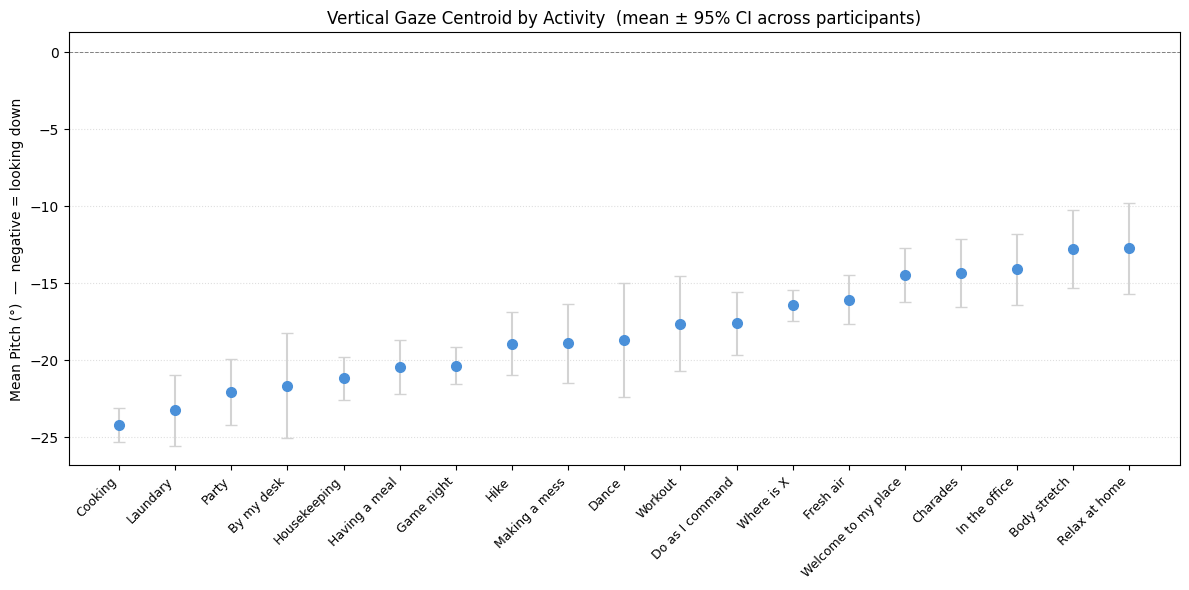

In [17]:
plot_centroids = (centroids[centroids["script"] != "S16-Simon_says"]
                  .sort_values("centroid_pitch")
                  .reset_index(drop=True))

labels = plot_centroids["script"].str.split("-", n=1).str[1].str.replace("_", " ")

fig, ax = plt.subplots(figsize=(12, 6))

ax.errorbar(
    x=range(len(plot_centroids)),
    y=plot_centroids["centroid_pitch"],
    yerr=plot_centroids["pitch_se"] * 1.96,  # 95% CI
    fmt="o", color="#4a90d9", ecolor="lightgray",
    elinewidth=1.5, capsize=4, markersize=7
)

ax.set_xticks(range(len(plot_centroids)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_ylabel("Mean Pitch (°)  —  negative = looking down")
ax.set_title("Vertical Gaze Centroid by Activity  (mean ± 95% CI across participants)")
ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "activity_pitch_centroids.png", dpi=150, bbox_inches="tight")
plt.show()


What we did:

We built a clean analysis pipeline for activity-based gaze analysis. Starting from 1,100 sessions, we applied a standard filter block — dropping 30 Hz sessions, noise-flagged sessions, sessions without gaze data, two-participant sessions, and duplicate recordings (keeping each person's earliest session per activity). This left 809 sessions from 193 participants across 20 activities. We excluded Simon Says from all visualizations as it involves a structured instruction role that isn't representative of natural gaze behavior. For each session we applied calibration trimming using the 50/50 method before preprocessing.

What we found:
1. Cooking shows the most downward gaze of any activity — participants looked on average −24° below center, tightly concentrated around straight ahead in yaw. This is consistent with looking at a counter or cutting board directly in front of them.

2. Activities separate clearly along the vertical gaze axis — pitch centroid alone orders all 19 activities along a meaningful continuum from near-field manipulation tasks (cooking, laundry, housekeeping) to open-space and social activities (relax at home, body stretch, charades). The range spans about 12° from most downward to least downward.

3. Yaw barely varies across activities — all activity centroids fall within ±2° of center horizontally. People tend to look straight ahead regardless of what they're doing. The meaningful behavioral signal is in pitch, not yaw.

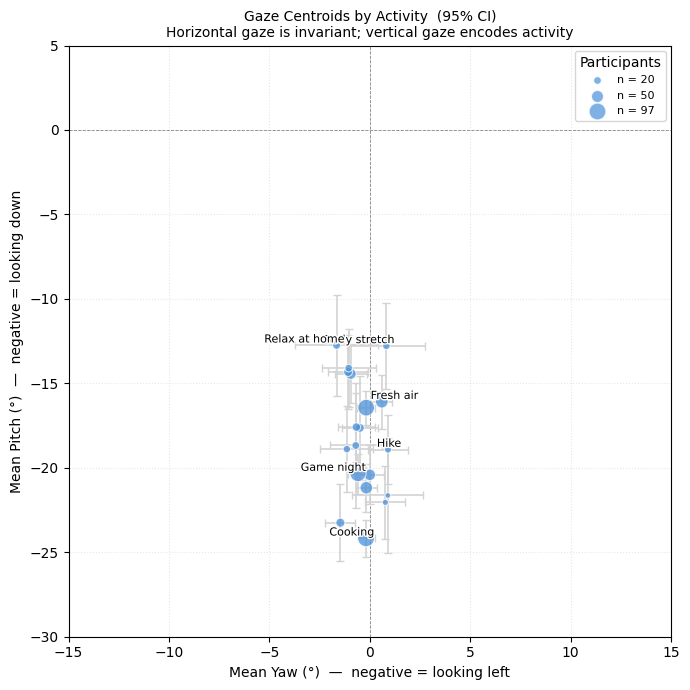

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(7, 7))

# Plot all activity centroids
sc = ax.scatter(
    plot_centroids["centroid_yaw"],
    plot_centroids["centroid_pitch"],
    s=plot_centroids["n"] * 1.5,   # size proportional to n
    color="#4a90d9", alpha=0.75, zorder=3, edgecolors="white", linewidths=0.8
)

# Error bars
ax.errorbar(
    plot_centroids["centroid_yaw"],
    plot_centroids["centroid_pitch"],
    xerr=plot_centroids["yaw_se"] * 1.96,
    yerr=plot_centroids["pitch_se"] * 1.96,
    fmt="none", ecolor="lightgray", elinewidth=1.2, capsize=3, zorder=2
)

# Label only the notable extremes — avoids clutter
label_these = {
    "S7-Cooking":        ("right", 6),
    "S1-Relax_at_home":  ("right", 6),
    "S4-Body_stretch":   ("right", 6),
    "S18-Hike":          ("left", -8),
    "S19-Fresh_air":     ("left", -8),
    "S12-Game_night":    ("right", 6),
}
for _, row in plot_centroids.iterrows():
    if row["script"] in label_these:
        side, offset = label_these[row["script"]]
        label = row["script"].split("-", 1)[1].replace("_", " ")
        ax.annotate(
            label,
            (row["centroid_yaw"], row["centroid_pitch"]),
            textcoords="offset points", xytext=(offset, 2),
            fontsize=8, ha=side,
            path_effects=[pe.withStroke(linewidth=2, foreground="white")]
        )

# Crosshairs and symmetric axes — this is the key visual argument
ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", zorder=1)
ax.axvline(0, color="gray", linewidth=0.6, linestyle="--", zorder=1)
ax.set_xlim(-15, 15)
ax.set_ylim(-30, 5)

ax.set_xlabel("Mean Yaw (°)  —  negative = looking left", fontsize=10)
ax.set_ylabel("Mean Pitch (°)  —  negative = looking down", fontsize=10)
ax.set_title("Gaze Centroids by Activity  (95% CI)\nHorizontal gaze is invariant; vertical gaze encodes activity", fontsize=10)
ax.grid(linestyle=":", alpha=0.3)

# Size legend
for n_val in [20, 50, 97]:
    ax.scatter([], [], s=n_val * 1.5, color="#4a90d9", alpha=0.7,
               label=f"n = {n_val}", edgecolors="white", linewidths=0.8)
ax.legend(title="Participants", framealpha=0.8, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "activity_centroids_2d.png", dpi=150, bbox_inches="tight")
plt.show()


In [19]:
# Spatial spread: between-participant SD of gaze centroids per activity
spread = (participant_means[participant_means["script"] != "S16-Simon_says"]
          .groupby("script")
          .agg(
              pitch_sd = ("mean_pitch", "std"),
              yaw_sd   = ("mean_yaw",   "std"),
              n        = ("fake_name",  "count"),
          )
          .reset_index()
          .sort_values("pitch_sd")
          .reset_index(drop=True))

print(spread.to_string())


                    script  pitch_sd    yaw_sd   n
0                S20-Party  3.944822  1.845685  13
1                 S18-Hike  4.308485  2.072448  17
2            S2-Where_is_X  5.009736  2.233888  96
3      S15-Do_as_I_command  5.208788  2.372295  25
4        S17-In_the_office  5.234460  3.054250  20
5         S10-Housekeeping  5.317265  2.003575  54
6   S3-Welcome_to_my_place  5.567448  2.497390  39
7               S7-Cooking  5.567835  2.136323  97
8          S4-Body_stretch  5.627611  4.259862  19
9           S12-Game_night  5.698249  2.383240  89
10        S9-Making_a_mess  5.708422  2.943353  19
11          S14-By_my_desk  5.724559  2.978440  11
12            S13-Charades  5.874845  2.635213  27
13           S19-Fresh_air  6.012104  1.999110  55
14        S8-Having_a_meal  6.035380  2.459389  46
15            S11-Laundary  6.201164  2.021713  28
16        S1-Relax_at_home  7.121577  4.984205  22
17              S5-Workout  8.007438  2.306930  26
18                S6-Dance  8.6

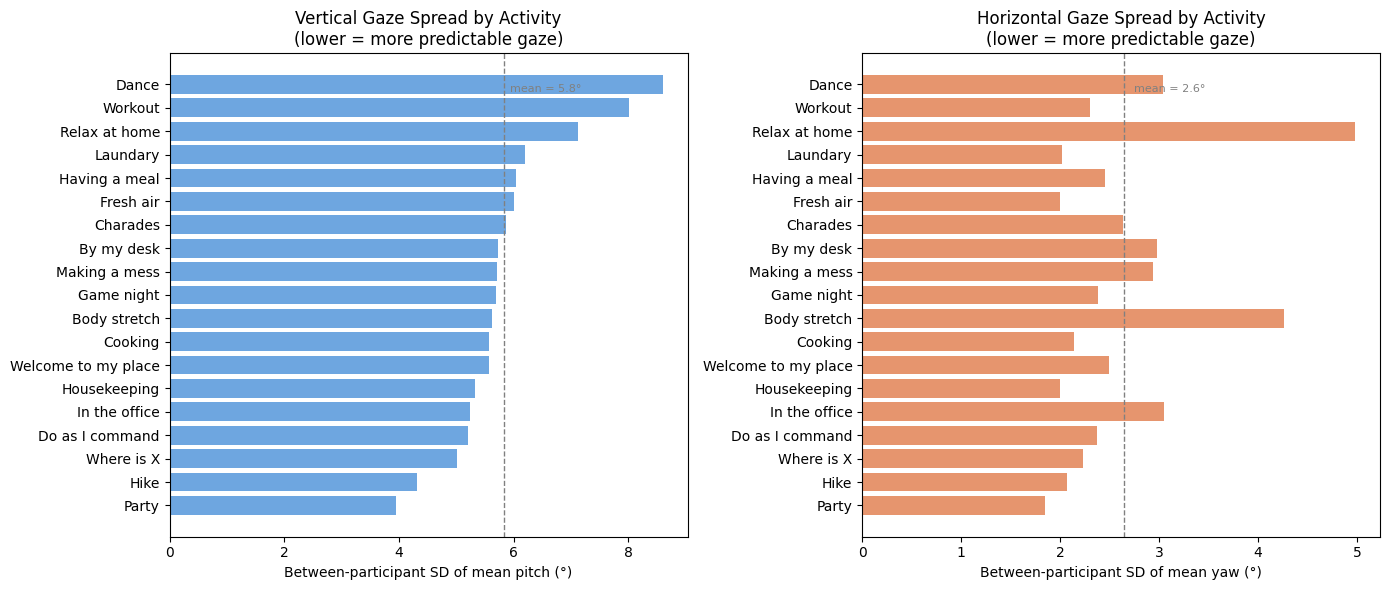

In [20]:
labels_spread = spread["script"].str.split("-", n=1).str[1].str.replace("_", " ")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Pitch SD ---
ax = axes[0]
bars = ax.barh(labels_spread, spread["pitch_sd"], color="#4a90d9", alpha=0.8)
ax.set_xlabel("Between-participant SD of mean pitch (°)")
ax.set_title("Vertical Gaze Spread by Activity\n(lower = more predictable gaze)")
ax.axvline(spread["pitch_sd"].mean(), color="gray", linestyle="--", linewidth=1)
ax.text(spread["pitch_sd"].mean() + 0.1, len(spread) - 1,
        f"mean = {spread['pitch_sd'].mean():.1f}°", fontsize=8, va="top", color="gray")

# --- Yaw SD ---
ax = axes[1]
ax.barh(labels_spread, spread["yaw_sd"], color="#e07b4a", alpha=0.8)
ax.set_xlabel("Between-participant SD of mean yaw (°)")
ax.set_title("Horizontal Gaze Spread by Activity\n(lower = more predictable gaze)")
ax.axvline(spread["yaw_sd"].mean(), color="gray", linestyle="--", linewidth=1)
ax.text(spread["yaw_sd"].mean() + 0.1, len(spread) - 1,
        f"mean = {spread['yaw_sd'].mean():.1f}°", fontsize=8, va="top", color="gray")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "activity_gaze_spread.png", dpi=150, bbox_inches="tight")
plt.show()
